In [123]:
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from scipy.io import loadmat
from sklearn.decomposition import PCA

from perceptual_straightening.modules.elbo import ELBO

In [ ]:
# load data
save_params_path = Path('fitted_parameters')
data_path = Path('data')
monkey_id = 2
n_bins = 30

pkl_file = Path(save_params_path) / f"value_manifold_monkey{monkey_id}_{n_bins}bins_params.pkl"
with open(pkl_file, 'rb') as file:
    elbo = pickle.load(file)

bin_min = 0
bin_max = 38
bin_range = np.linspace(bin_min, bin_max, n_bins)

In [125]:
# compute PC-reduced perceptual locations
pca_fit = PCA(n_components=2)

pca_fit.fit(elbo.x.detach())
pc_fit = pca_fit.components_

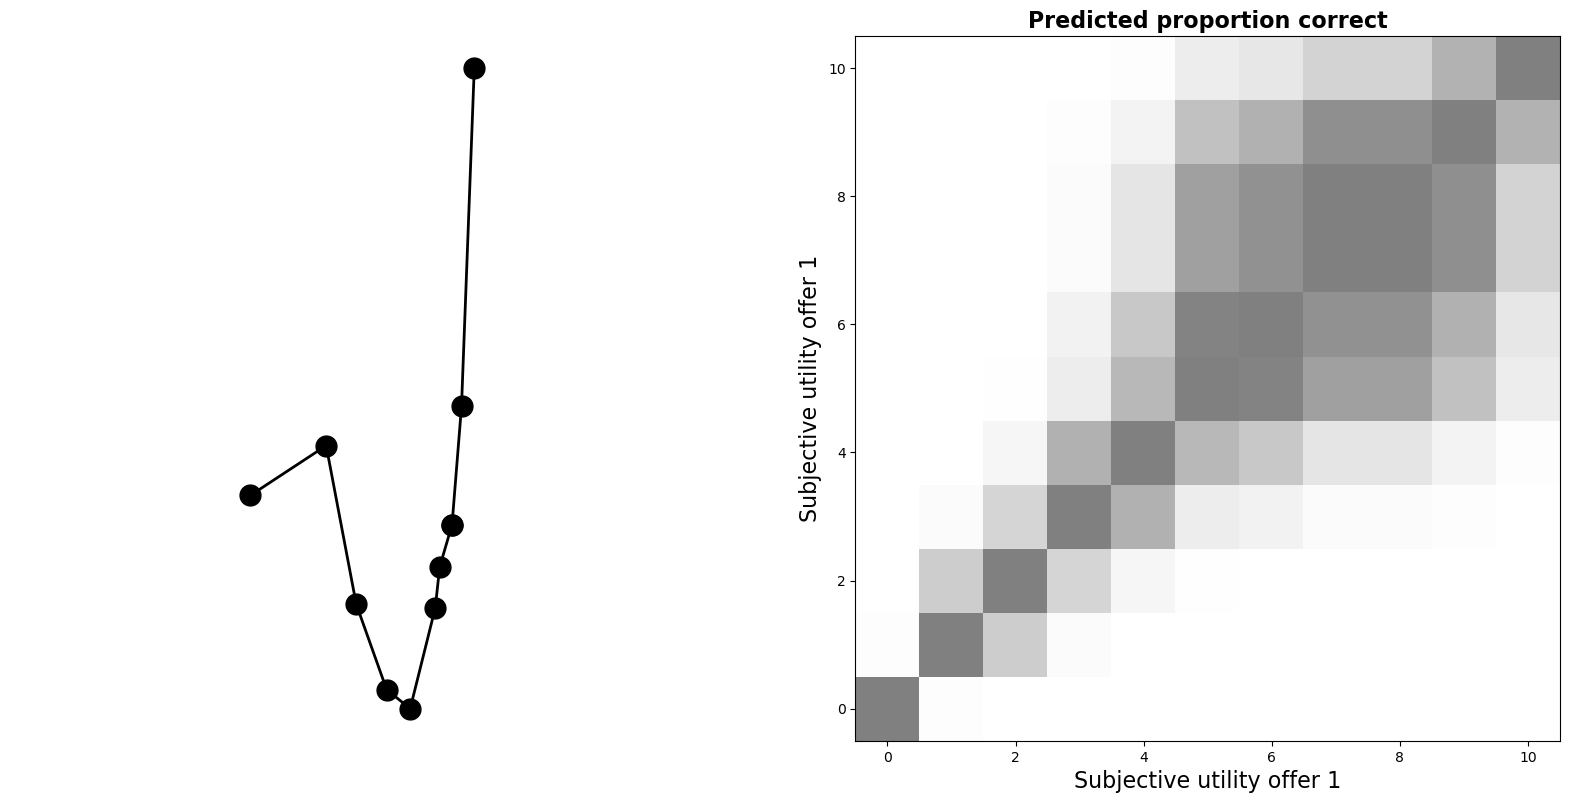

In [126]:
fig, axs = plt.subplots(1, 2, figsize=(20, 10))
axs[0].plot(pc_fit[0, :], pc_fit[1, :], '-ko', markersize=15, linewidth=2)
axs[0].set_xlabel('PC 1')
axs[0].set_ylabel('PC 2')
axs[0].set_box_aspect(1)  
axs[0].set_aspect('equal') 
axs[0].set_axis_off()

# sns.heatmap(elbo.p.detach().numpy().squeeze(), xticklabels=np.round(bin_range), yticklabels=np.round(bin_range), ax=axs[1], cmap='gray', vmin=0, vmax=1)
axs[1].imshow(elbo.p.detach().numpy().squeeze(), cmap='gray', vmin=0, vmax=1)
axs[1].invert_yaxis()
axs[1].set_title('Predicted proportion correct', fontsize=16, fontweight='bold')
# axs[1].set_box_aspect(1)  
axs[1].set_aspect('equal') 
axs[1].set_xlabel('Subjective utility offer 1', fontsize=16)
axs[1].set_ylabel('Subjective utility offer 1', fontsize=16)
plt.show()

In [127]:
print(f'Inferred proportion correct: {np.mean(elbo.p.detach().numpy())}')
print(f'Mean curvature: {np.rad2deg(np.mean(elbo.mu_post_c.detach().numpy()))}')
print(f'Number of dimensions: {elbo.x.shape[0]}')

Inferred proportion correct: 0.8467164039611816
Mean curvature: 22.683506473716573
Number of dimensions: 10


In [128]:
# load discriminability matrix
n_corr_obs = np.array(loadmat(Path(data_path) / f'n_corr_obs_monkey{monkey_id}_{n_bins + 1}bins.mat')['corr_offer_mat'], dtype=np.float32)
n_total_obs = np.array(loadmat(Path(data_path) / f'n_total_obs_monkey{monkey_id}_{n_bins + 1}bins.mat')['total_offer_mat'], dtype=np.float32)

In [129]:
# remove missing trials
mask = (n_total_obs != 0).flatten()

p_est = elbo.p.detach().flatten()[mask]
n_corr_clean = n_corr_obs.flatten()[mask]
n_total_clean = n_total_obs.flatten()[mask]

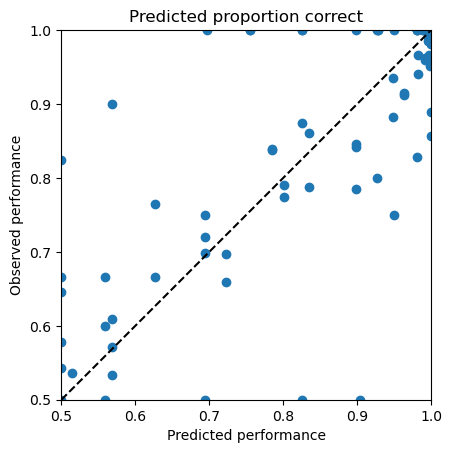

MSE: 0.017015933990478516


In [130]:
fig, axs = plt.subplots()
axs.set_title('Predicted proportion correct')
axs.scatter(p_est, (n_corr_clean / n_total_clean).flatten())
axs.plot([0.5, 1], [0.5, 1], 'k--')
axs.set_xlim(0.5, 1)
axs.set_ylim(0.5, 1)
axs.set_xlabel('Predicted performance')
axs.set_ylabel('Observed performance')
axs.set_box_aspect(1)

plt.show()

mse = np.mean(((n_corr_clean / n_total_clean).flatten() - p_est.numpy())**2)
print(f"MSE: {mse}")

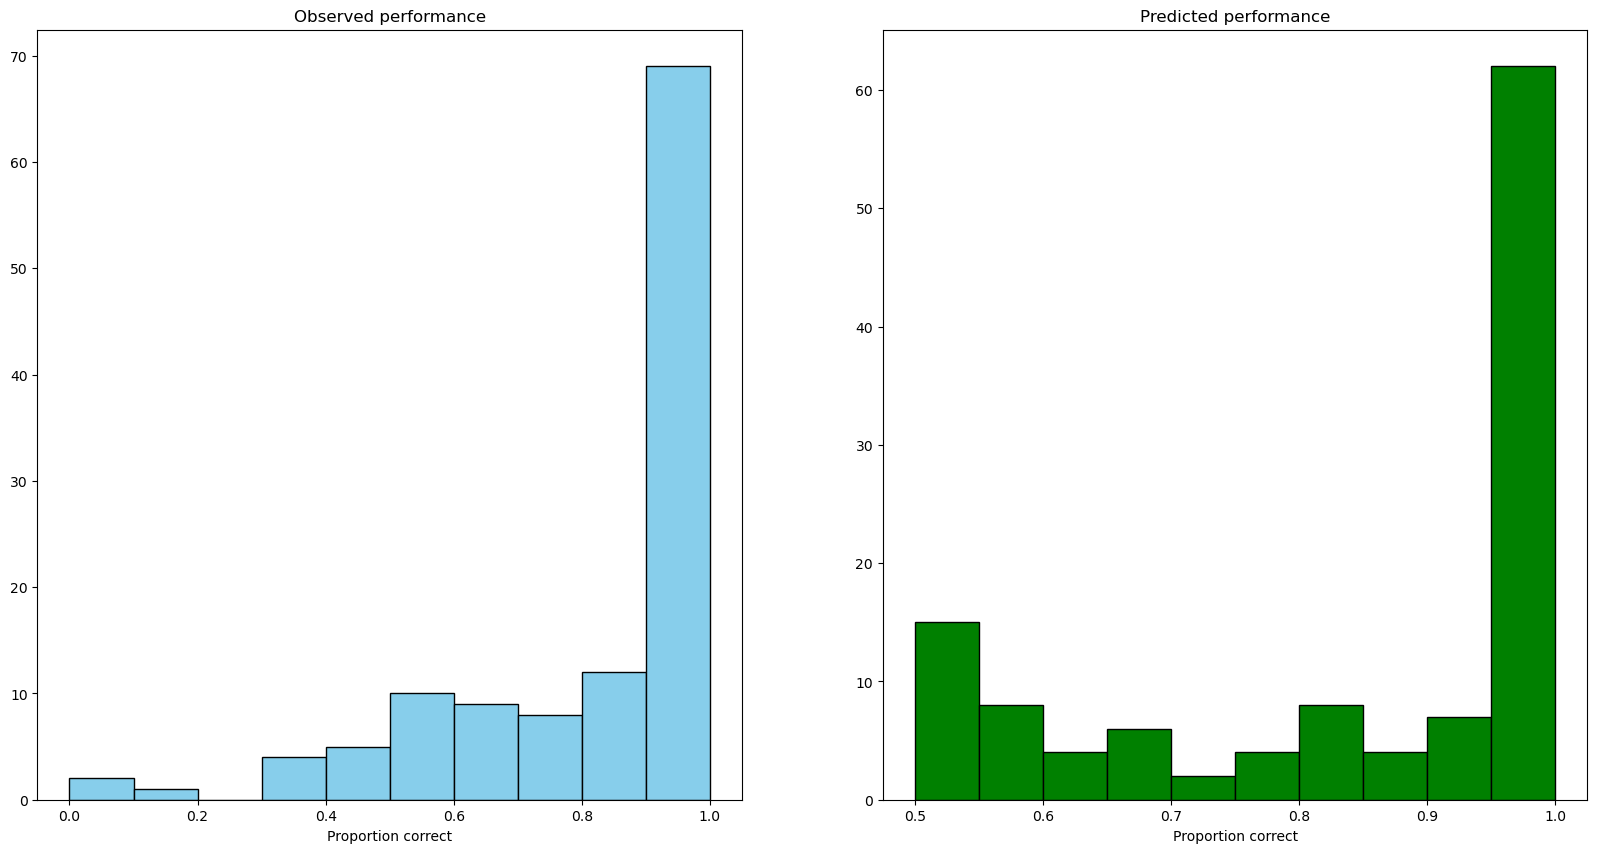

In [131]:
fig, axs = plt.subplots(1, 2, figsize=(20, 10))
axs[0].hist((n_corr_clean / n_total_clean).flatten(), color='skyblue', edgecolor='black')
axs[0].set_title('Observed performance')
axs[0].set_xlabel('Proportion correct')

axs[1].hist(p_est.numpy(), edgecolor='black', color='green')
axs[1].set_title('Predicted performance')
axs[1].set_xlabel('Proportion correct')
plt.show()

In [132]:
# compute centered Gram matrix and look at Eigenvalue spectrum
n_dim = elbo.x.shape[0]

X = elbo.x
H = torch.eye(n_dim) - torch.ones((n_dim, n_dim)) / n_dim # centering matrix
B = (H @ X) @ (H @ X).T

# compute eigenvalues
L, Q = torch.linalg.eigh(B)
print(f'Eigenvalues: {L}') 
print(f'Matrix rank: {torch.linalg.matrix_rank(B, hermitian=True)}')

Eigenvalues: tensor([-2.3872e-05,  2.5987e-06,  1.7696e-05,  9.4941e-04,  1.2312e-03,
         1.9826e-02,  4.2126e-01,  7.7635e-01,  2.7561e+00,  1.0943e+03],
       grad_fn=<LinalgEighBackward0>)
Matrix rank: 5


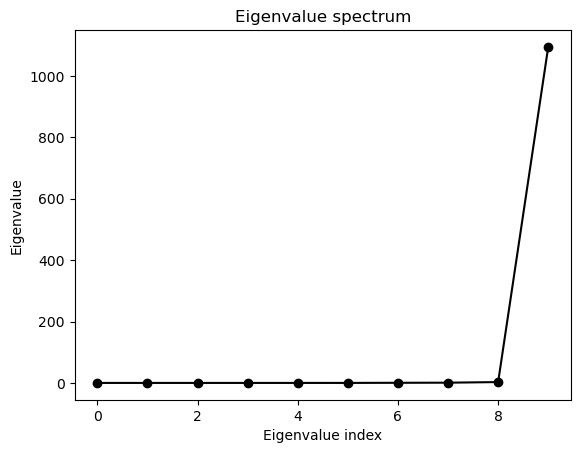

In [133]:
plt.plot(L.detach().numpy(), color='black', marker='o')
plt.ylabel('Eigenvalue')
plt.xlabel('Eigenvalue index')
plt.title('Eigenvalue spectrum')
plt.show()